In [26]:
#Import Libraries
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 90
print('Libraries imported successfully')

Libraries imported successfully


In [27]:
#Load Data
df = pd.read_excel('../data/raw/FoodCompositionTable.xlsx')
print('Shape:', df.shape)
df.head(10)

Shape: (631, 18)


,S.N.,Food Commodity,Edible Portion,Moisture (g),Protein (g),Fat (g),Carbohydrate (g),Minerals (g),Fiber (g),Energy (KCal),Calcium (mg),Phosphorus (mg),Iron (mg),Carotene (µg),Vitamin C (mg),Thiamine (mg),Riboflavin (mg),Niacin (mg)
0,1,Amaranth seed,100,10.6,9.4,7.17,68.1,2.6,2.2,375,37,529.1,5.2,-,-,-,-,-
1,2,Barely,100,12.5,11.5,1.3,69.6,1.2,3.9,336,26,215,1.7,10,0,0.47,0.2,5.4
2,3,Buck wheat (whole),74,11.3,10.3,2.4,65.1,2.3,8.6,323,64,355,15.5,0,0,0.9,0.34,4.4
3,4,Bajra,84,12.4,11.6,5,67.5,2.3,1.2,361,42,296,8,132,0,0.33,0.25,2.3
4,5,Bamboo seed,100,7.8,13.1,1.1,75.9,1.1,0.9,367,37,162,6.4,-,-,0.17,0.12,1.1
5,6,Buckwheat flour,-,12.2,6.1,1.3,69.2,3.1,7.8,313,-,-,5.6,-,-,-,-,-
6,7,Foxtail millet,79,11.2,12.3,4.3,60.9,3.3,8,331,31,290,12.9,32,-,0.59,0.11,3.2
7,8,Finger millet (Ragi),100,13.1,7.3,1.3,72,2.7,3.6,328,344,283,3.9,42,-,0.42,0.19,1.1
8,9,Prosomillet (chino),100,8.67,11,4.22,72.9,3.25,1,378,8,28.5,3,-,-,-,-,-
9,10,French millet,59,11.9,12.5,1.1,70.4,1.9,2.2,341,14,206,5,0,-,0.2,0.18,2.3


In [28]:
#Rename Columns
# short consistent names
rename_map = {
    'S.N.': 'sn', 'Food Commodity': 'food_name', 'Edible Portion': 'edible_portion',
    'Moisture (g)': 'moisture', 'Protein (g)': 'protein', 'Fat (g)': 'fat',
    'Carbohydrate (g)': 'carbs', 'Minerals (g)': 'minerals', 'Fiber (g)': 'fiber',
    'Energy (KCal)': 'calories', 'Calcium (mg)': 'calcium', 'Phosphorus (mg)': 'phosphorus',
    'Iron (mg)': 'iron', 'Carotene (µg)': 'carotene', 'Vitamin C (mg)': 'vitamin_c',
    'Thiamine (mg)': 'thiamine', 'Riboflavin (mg)': 'riboflavin', 'Niacin (mg)': 'niacin',
}
df = df.rename(columns=rename_map)

# delete unnecessary columns - keep only important nutrients
drop_cols = ['edible_portion', 'moisture', 'minerals', 'phosphorus', 'carotene',
             'thiamine', 'riboflavin', 'niacin']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print('Columns kept (important nutrients):', df.columns.tolist())

Columns kept (important nutrients): ['sn', 'food_name', 'protein', 'fat', 'carbs', 'fiber', 'calories', 'calcium', 'iron', 'vitamin_c']


In [29]:
#Nutrient Columns
numeric_columns = [
    'protein', 'fat', 'carbs', 'fiber',
    'calories', 'calcium', 'iron', 'vitamin_c'
]
print('Important nutrients only:', len(numeric_columns))

Important nutrients only: 8


In [30]:
#Find Placeholders
# '-', '?', 'ND', '–' mean "not available"
placeholders = ['-', '?', 'ND', 'trace', 'traces', 'Colour', 'Red colour', '–', '—']
for ph in placeholders:
    n = int((df[numeric_columns].astype(str) == ph).sum().sum())
    if n:
        print(f'Placeholder {ph!r}: {n} cells')

Placeholder '-': 566 cells
Placeholder 'ND': 8 cells
Placeholder 'trace': 1 cells
Placeholder 'traces': 16 cells
Placeholder 'Colour': 1 cells
Placeholder 'Red colour': 2 cells
Placeholder '–': 296 cells


In [31]:
#Convert to numbers
PH = {'-', '?', 'ND', 'trace', 'traces', 'Colour', 'Red colour', '–', '—'}

def smart_number(v):
    """Cell -> float. NaN for placeholders; keeps '22300IU', '0.8 Traces', '1846.65*'."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in PH:
        return np.nan
    iu = re.search(r'(\d+(?:\.\d+)?)\s*iu', s)
    if iu:
        return round(float(iu.group(1)) * 0.6, 2)   # IU -> ug
    m = re.search(r'\d+(?:\.\d+)?', s)
    return float(m.group()) if m else np.nan

# annotated values that are not plain numbers
odd = df[numeric_columns].astype(str).apply(lambda c: c[~c.str.match(r'^-?\d+(\.\d+)?$')])
odd = odd.stack().dropna().unique()
print('Non-plain values found (sample):', list(odd)[:12])

for col in numeric_columns:
    df[col] = df[col].map(smart_number).astype(float)

print('\nData types after conversion:')
df[numeric_columns].dtypes.value_counts()

Non-plain values found (sample): ['-', 'Red colour', 'Colour', '0.8 Traces', 'ND', '–', 'trace', 'traces']

Data types after conversion:


float64    8
Name: count, dtype: int64

In [32]:
#Missing value analysis
missing = df[numeric_columns].isnull().sum().sort_values(ascending=False)
missing

vitamin_c    329
iron         190
fiber        160
calcium      136
carbs         38
fat           28
protein       23
calories      16
dtype: int64

In [33]:
missing_pct = df[numeric_columns].isnull().mean().mul(100).sort_values(ascending=False).round(2)
missing_pct

vitamin_c    52.14
iron         30.11
fiber        25.36
calcium      21.55
carbs         6.02
fat           4.44
protein       3.65
calories      2.54
dtype: float64

In [34]:
print('Total missing cells:', int(df[numeric_columns].isna().sum().sum()))
print('Rows with at least one missing value:', int(df[numeric_columns].isna().any(axis=1).sum()))

Total missing cells: 920
Rows with at least one missing value: 409


In [35]:
#Stats and Impossible values
df[numeric_columns].describe().T[['min', 'max', 'mean', 'std']].round(2)

,min,max,mean,std
protein,0.00,70.8,8.65,9.49
fat,0.00,100.0,7.76,17.98
carbs,0.00,346.0,30.70,29.88
fiber,0.00,330.0,3.49,15.64
calories,2.60,900.0,215.62,194.31
calcium,2.44,3095.0,153.37,319.77
iron,0.02,120.0,5.69,11.06
vitamin_c,0.00,9514.0,58.33,548.57


In [36]:
# negative nutrients are impossible
neg = df[(df[numeric_columns] < 0).any(axis=1)]
print('Rows with negative values:', len(neg))
neg[['food_name'] + numeric_columns]

Rows with negative values: 0


,food_name,protein,fat,carbs,fiber,calories,calcium,iron,vitamin_c


In [37]:
# impossible: fiber>50, carbs>100, cal>900
suspicious = df[
    (df['fiber'] > 50) | (df['carbs'] > 100) | (df['calories'] > 900)
]
print('Suspicious extreme rows:', len(suspicious))
suspicious[['food_name', 'fiber', 'carbs', 'calories']]

Suspicious extreme rows: 2


,food_name,fiber,carbs,calories
219,Water chesnut dry,330.0,68.9,70.0
255,Blackgram+Garlic Maseura,1.2,346.0,346.0


In [38]:
#Duplicate Analysis
print('Exact duplicate rows:', int(df.duplicated().sum()))
print('Duplicate food names:', int(df['food_name'].duplicated().sum()))
print('Food names appearing > 1 time:', int(df['food_name'].duplicated().nunique()))

Exact duplicate rows: 6
Duplicate food names: 10
Food names appearing > 1 time: 2


In [39]:
dup = df[df['food_name'].duplicated(keep=False)].sort_values('food_name')
dup[['sn', 'food_name', 'protein', 'fat', 'calories']]

,sn,food_name,protein,fat,calories
229,227,Garlic dry,6.0,0.1,145.0
352,344,Garlic dry,6.3,0.1,145.0
328,326,Rose sppple,0.7,0.2,39.0
334,326,Rose sppple,0.7,0.2,39.0
331,329,Sapota,0.7,1.1,98.0
337,329,Sapota,0.7,1.1,98.0
329,327,Seethphal,1.6,0.4,104.0
335,327,Seethphal,1.6,0.4,104.0
330,328,Strawberry,0.7,0.2,44.0
336,328,Strawberry,0.7,0.2,44.0


In [40]:
#Remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after removing exact duplicates:', len(df))

Rows after removing exact duplicates: 625


In [41]:
#Remove Section Headers
# 'B. PULSES & LEGUMES' etc. are section headers, not foods
cat_mask = df['sn'].astype(str).str.match(r'^[A-Z]\.\s')
print('Section-header rows found:', int(cat_mask.sum()))
df.loc[cat_mask, ['sn', 'food_name']]

Section-header rows found: 3


,sn,food_name
40,B. PULSES & LEGUMES,NaN
82,C. GREEN LEAFY VEGETABLES,NaN
150,D. OTHER VEGETABLES,NaN


In [42]:
# section headers are not foods - drop them, no category column needed
df = df[~cat_mask].reset_index(drop=True)
print('Rows after removing section-header rows:', len(df))

Rows after removing section-header rows: 622


In [43]:
#Fix Duplicated Food names
# Walnut twice -> keep first
df = df.drop_duplicates(subset=['food_name'], keep='first').reset_index(drop=True)
print('Walnut rows now:', len(df[df['food_name'] == 'Walnut']))

# Garlic dry twice -> average values
garlic_mask = df['food_name'] == 'Garlic dry'
if garlic_mask.sum() > 1:
    avg = df.loc[garlic_mask, numeric_columns].mean()
    df = df[~garlic_mask]
    df.loc[garlic_mask.idxmax(), numeric_columns] = avg

print('Garlic dry rows now:', len(df[df['food_name'] == 'Garlic dry']))
print('Duplicate names left:', int(df['food_name'].duplicated().sum()))
print('Rows now:', len(df))

Walnut rows now: 1
Garlic dry rows now: 1
Duplicate names left: 0
Rows now: 620


In [44]:
#Outlier Detection
# outside Q1/Q3 ± 1.5*IQR = outlier
outlier_summary = {}
for col in ['protein', 'fat', 'carbs', 'fiber', 'calories']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n = int(((df[col] < lo) | (df[col] > hi)).sum())
    outlier_summary[col] = n
print('Outliers per feature:')
print(pd.Series(outlier_summary))

Outliers per feature:
protein      11
fat         102
carbs         1
fiber        45
calories     13
dtype: int64


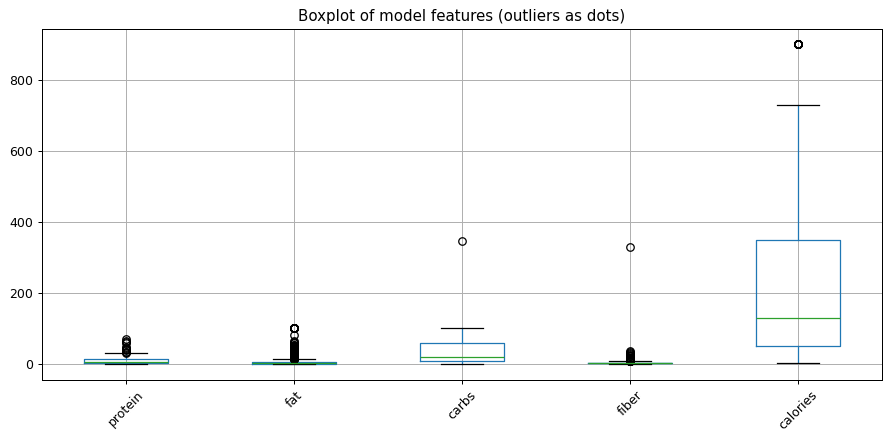

In [45]:
plt.figure(figsize=(10, 5))
df[['protein', 'fat', 'carbs', 'fiber', 'calories']].boxplot()
plt.title('Boxplot of model features (outliers as dots)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# extreme dots = oils/nuts/dried items (real but unusual)
print('Examples of flagged extreme foods:')
for col in ['fiber', 'carbs', 'calories']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    hi = Q3 + 1.5 * (Q3 - Q1)
    top = df[df[col] > hi].sort_values(col, ascending=False).head(3)
    print(f'\n[{col} > {hi:.1f}]:')
    print(top[['food_name', col]].to_string(index=False))

Examples of flagged extreme foods:

[fiber > 6.5]:
        food_name  fiber
Water chesnut dry  330.0
   Safflower seed   34.9
   Coriander, dry   32.6

[carbs > 134.5]:
               food_name  carbs
Blackgram+Garlic Maseura  346.0

[calories > 796.0]:
            food_name  calories
             Ghee cow     900.0
       Ghee (Buffalo)     900.0
Vegetable cooking oil     900.0


In [47]:
#ML Imputation (IterativeImputer)
# estimate missing values from correlated nutrients, clip to observed range
impute_cols = numeric_columns
before = {c: int(df[c].isna().sum()) for c in impute_cols}
obs_bounds = {c: (df[c].min(), df[c].max()) for c in impute_cols}

imputer = IterativeImputer(max_iter=20, random_state=42, n_nearest_features=10)
X = imputer.fit_transform(df[impute_cols].astype(float))
for i, c in enumerate(impute_cols):
    lo, hi = obs_bounds[c]
    df[c] = np.round(np.clip(X[:, i], lo, hi), 2)

summary = pd.DataFrame({'missing_before': pd.Series(before), 'missing_after': 0})
summary

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,missing_before,missing_after
protein,20,0
fat,25,0
carbs,35,0
fiber,156,0
calories,13,0
calcium,133,0
iron,187,0
vitamin_c,326,0


In [48]:
print('Total missing before:', int(summary['missing_before'].sum()))
print('Total missing after :', int(df[impute_cols].isna().sum().sum()))

Total missing before: 895
Total missing after : 0


In [49]:
#Feature Scaling
# units differ (g, mg, ug, kcal) -> scale so clustering is not dominated
scaler = StandardScaler()
X = scaler.fit_transform(df[numeric_columns])
scaled_df = pd.DataFrame(X, columns=numeric_columns)
scaled_df.describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
protein,0.0,1.001,-0.935,6.250
fat,-0.0,1.001,-0.428,5.235
carbs,-0.0,1.001,-1.004,10.635
fiber,0.0,1.001,-0.266,23.917
calories,0.0,1.001,-1.102,3.489
calcium,0.0,1.001,-0.558,9.732
iron,0.0,1.001,-0.607,10.840
vitamin_c,0.0,1.001,-0.155,24.739


In [52]:
output_dir = r"C:\Users\user\OneDrive\Documents\Nepali-Diet-Recommender\backend\data\processed"

os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    "nepali_food_cleaned.csv"
)

df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully.")
print("Saved at:", output_file)
print("Rows:", len(df))
print("Columns:", len(df.columns))


Cleaned dataset saved successfully.
Saved at: C:\Users\user\OneDrive\Documents\Nepali-Diet-Recommender\backend\data\processed\nepali_food_cleaned.csv
Rows: 620
Columns: 10


In [53]:
print(df.columns.tolist())

['sn', 'food_name', 'protein', 'fat', 'carbs', 'fiber', 'calories', 'calcium', 'iron', 'vitamin_c']


In [54]:
print(df.head().to_string())

  sn           food_name  protein   fat  carbs  fiber  calories  calcium  iron  vitamin_c
0  1       Amaranth seed      9.4  7.17   68.1    2.2     375.0     37.0   5.2      58.94
1  2              Barely     11.5  1.30   69.6    3.9     336.0     26.0   1.7       0.00
2  3  Buck wheat (whole)     10.3  2.40   65.1    8.6     323.0     64.0  15.5       0.00
3  4               Bajra     11.6  5.00   67.5    1.2     361.0     42.0   8.0       0.00
4  5         Bamboo seed     13.1  1.10   75.9    0.9     367.0     37.0   6.4      58.95


In [55]:
print("Total foods:", len(df))

Total foods: 620


In [56]:
# Meal category assignment

df["breakfast"] = 0
df["lunch"] = 0
df["dinner"] = 0

print(df[["food_name", "breakfast", "lunch", "dinner"]].head())

            food_name  breakfast  lunch  dinner
0       Amaranth seed          0      0       0
1              Barely          0      0       0
2  Buck wheat (whole)          0      0       0
3               Bajra          0      0       0
4         Bamboo seed          0      0       0


In [60]:
# Save food names for meal classification

food_name = df["food_name"]

food_name.to_csv(
    "../data/processed/food_names_for_meal_classification.csv",
    index=False
)

print("Saved", len(food_name), "food names.")


Saved 620 food names.


In [63]:
# Convert food names to lowercase for matching
food_name = df["food_name"].fillna("").str.lower()

# Breakfast
breakfast_keywords = [
    "bread", "roti", "naan", "chiura", "beaten rice",
    "oat", "porridge", "milk", "egg", "tea", "coffee",
    "corn flakes", "cereal"
]

# Lunch and dinner
lunch_dinner_keywords = [
    "rice", "dal", "pulse", "lentil", "bean",
    "vegetable", "curry", "meat", "chicken",
    "fish", "mutton", "noodle", "roti", "naan"
]

for keyword in breakfast_keywords:
    df.loc[food_name.str.contains(keyword, regex=False), "breakfast"] = 1

for keyword in lunch_dinner_keywords:
    mask = food_name.str.contains(keyword, regex=False)
    df.loc[mask, "lunch"] = 1
    df.loc[mask, "dinner"] = 1

In [64]:
df[["food_name", "breakfast", "lunch", "dinner"]].head(50)

,food_name,breakfast,lunch,dinner
0,Amaranth seed,1,0,0
1,Barely,1,1,0
2,Buck wheat (whole),1,0,0
3,Bajra,1,0,0
4,Bamboo seed,0,0,0
5,Buckwheat flour,1,0,1
6,Foxtail millet,1,0,0
7,Finger millet (Ragi),1,0,0
8,Prosomillet (chino),1,0,0
9,French millet,1,0,0


In [65]:
print("Breakfast:", df["breakfast"].sum())
print("Lunch:", df["lunch"].sum())
print("Dinner:", df["dinner"].sum())

Breakfast: 120
Lunch: 210
Dinner: 202


In [66]:
no_meal = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]

print("Foods with no meal category:", len(no_meal))

print(
    no_meal[["sn", "food_name"]]
    .to_string(index=False)
)

Foods with no meal category: 306
 sn                        food_name
  5                      Bamboo seed
 12             Maize green (tender)
 32           Sarvottam pitho (lito)
 63                   Katike Cow Pea
 79                    Mung (Titura)
 82                Amaranth (spined)
 83                Amaranth (tender)
 84               Asparagus (Kurilo)
 85                           Agathi
 86                   Aniseed leaves
 87                    Bethel leaves
 88                       Beet green
 91               Bottleguard leaves
 98                      Choisum Sag
 99                        Chukandar
100                    Chocho leaves
101                 Coriander leaves
103                    Celery leaves
104 Colocasia leaves (Black variety)
105 Colocasia leaves (Green variety)
106         Colocasia leaves (dried)
107                    Cowpea leaves
108                            Dundu
109                 Drumstick leaves
110                 Fenugreek leaves
111  

In [67]:
#Helper function

def assign_meal(food_names, breakfast=0, lunch=0, dinner=0):
    mask = df["food_name"].str.lower().str.strip().isin(
        [x.lower().strip() for x in food_names]
    )

    df.loc[mask, "breakfast"] = breakfast
    df.loc[mask, "lunch"] = lunch
    df.loc[mask, "dinner"] = dinner

#Breakfast
breakfast_foods = [
    "Amaranth seed",
    "Barely",
    "Buck wheat (whole)",
    "Bajra",
    "Buckwheat flour",
    "Foxtail millet",
    "Finger millet (Ragi)",
    "Prosomillet (chino)",
    "French millet",
    "Jowar",
    "Maize flour (yellow)",
    "Maize flour (white)",
    "Millet",
    "Uwa flour",
    "Semolina",
    "Sorghum",
    "Vermicelli",
    "Varagu",
    "Varagu flour",
    "Wheat flour (whole)",
    "Wheat flour (refined)",
    "Muesli",

    "Banana ripe",
    "Apple",
    "Papaya (ripe)",
    "Orange",
    "Grapes fruits( Marsh' seedless)",
    "Guava, country",
    "Guava , hill",
    "Pomegranate",
    "Pear",
    "Strawberry",
    "Sapota",

    "Curd",
    "Paneer",
    "Cheese",
    "Milk",

    "Maize dough( Dhindo)",
    "Sel",
    "jeri",
    "Biscuit, salty",
    "Biscuit, sweet",

    "Wai Wai",
    "Maggi",
    "Ezee",
    "Gimi Spaghetti",
    "Special Pasta",
    "Protein supplement powder",
    "High energy soya biscuit",
    "High energy Khajuri biscuit",
]


#Lunch

lunch_foods = [
    # grains
    "Rice",
    "Maize Dry",
    "Maize dry (Murali)",
    "Maize granular",
    "Barely",
    "Millet",
    "Jowar",

    # pulses
    "Bengal gram, Big, white (whole)",
    "Bengal gram medium, white",
    "Bengal gram, Dark brown big",
    "Bengal gram, light brown small",
    "Bengal gram, brown small",
    "Bengal gram, Small, White",
    "Black gram (Whole)",
    "Green gram (whole)",
    "Green peas dry",
    "Horsegram black",
    "Horsegram red",
    "Rajmah",
    "White peas big",
    "Cow Pea",
    "Peas (dry)",

    # vegetables
    "Potato",
    "Potato( Red)",
    "Cauliflower",
    "Cabbage green",
    "Cabbage purple",
    "Brinjal",
    "Bitter gourd",
    "Bottle gourd",
    "Pumpkin",
    "Spinach",
    "Tomato red",
    "Carrot",
    "Radish white",
    "Radish Pink",
    "Cucumber",
    "Ladies finger",
    "Drumstick",
    "Ridge gourd",
    "Snakegourd",
    "Ashgourd",
    "Plantain green",
    "Papaya green",

    # meat/fish
    "Rahu",
    "Katla",
    "Hisla",
    "Prawn",
    "Crab small",
    "Pork muscle",
    "Buff Sausage",
    "Liver , sheep",
    "Venison",

    # traditional foods
    "Gundurk(Mustard)",
    "Mulako Sinki",
    "Blackgram+Colocosia tuber Maseura",
    "Blackgram+Colocosia tuber+Gundruk Maseura",
    "Blackgram+Ashgourd (kubindo) Maseura",
    "Blackgram+Garlic Maseura",
    "Blackgram+Cabbage Maseura",
    "Blackgram+Raddish Maseura",
    "Blackgram+Cauliflower Maseura",

    "Dhindo",
    "Dal",
    "Tarkari",
]


#Dinner

dinner_foods = [
    # grains / staples
    "Rice",
    "Maize Dry",
    "Millet",
    "Jowar",
    "Wheat flour (whole)",
    "Wheat flour (refined)",
    "Buckwheat flour",
    "Maize flour (yellow)",
    "Maize flour (white)",

    # pulses
    "Bengal gram, Big, white (whole)",
    "Black gram (Whole)",
    "Green gram (whole)",
    "Rajmah",
    "Cow Pea",
    "Peas (dry)",

    # vegetables
    "Potato",
    "Cauliflower",
    "Cabbage green",
    "Cabbage purple",
    "Brinjal",
    "Bottle gourd",
    "Pumpkin",
    "Spinach",
    "Tomato red",
    "Carrot",
    "Radish white",
    "Cucumber",
    "Ladies finger",
    "Drumstick",
    "Ridge gourd",
    "Snakegourd",
    "Ashgourd",

    # meat/fish
    "Rahu",
    "Katla",
    "Hisla",
    "Prawn",
    "Crab small",
    "Pork muscle",
    "Venison",

    # traditional
    "Gundurk(Mustard)",
    "Mulako Sinki",
    "Blackgram+Colocosia tuber Maseura",
    "Blackgram+Colocosia tuber+Gundruk Maseura",
    "Blackgram+Ashgourd (kubindo) Maseura",
    "Blackgram+Garlic Maseura",
    "Blackgram+Cabbage Maseura",
    "Blackgram+Raddish Maseura",
    "Blackgram+Cauliflower Maseura",

    # common prepared foods
    "Buff Momo",
    "Paneer Momo",
    "Paneer+Veg Momo",
    "Samosa",
    "Aaluchap",
    "Pakauda",
]


#apply categories

assign_meal(
    breakfast_foods,
    breakfast=1
)

assign_meal(
    lunch_foods,
    lunch=1
)

assign_meal(
    dinner_foods,
    dinner=1
)




In [68]:

print("Breakfast:", df["breakfast"].sum())
print("Lunch:", df["lunch"].sum())
print("Dinner:", df["dinner"].sum())

print("\nMeal category distribution:")
print(
    df[["breakfast", "lunch", "dinner"]].sum()
)

print("\nFoods with NO meal category:")

no_category = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]

print(
    no_category[
        ["sn", "food_name"]
    ].to_string(index=False)
)

Breakfast: 112
Lunch: 168
Dinner: 202

Meal category distribution:
breakfast    112
lunch        168
dinner       202
dtype: int64

Foods with NO meal category:
 sn                        food_name
  5                      Bamboo seed
 12             Maize green (tender)
 32           Sarvottam pitho (lito)
 63                   Katike Cow Pea
 79                    Mung (Titura)
 82                Amaranth (spined)
 83                Amaranth (tender)
 84               Asparagus (Kurilo)
 85                           Agathi
 86                   Aniseed leaves
 87                    Bethel leaves
 88                       Beet green
 91               Bottleguard leaves
 98                      Choisum Sag
 99                        Chukandar
100                    Chocho leaves
101                 Coriander leaves
103                    Celery leaves
104 Colocasia leaves (Black variety)
105 Colocasia leaves (Green variety)
106         Colocasia leaves (dried)
107                    Co

In [69]:
df[
    ["food_name", "breakfast", "lunch", "dinner"]
].head(50)

,food_name,breakfast,lunch,dinner
0,Amaranth seed,1,0,0
1,Barely,0,1,0
2,Buck wheat (whole),1,0,0
3,Bajra,1,0,0
4,Bamboo seed,0,0,0
5,Buckwheat flour,0,0,1
6,Foxtail millet,1,0,0
7,Finger millet (Ragi),1,0,0
8,Prosomillet (chino),1,0,0
9,French millet,1,0,0


In [70]:

df["food_name_clean"] = (
    df["food_name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

df[["breakfast", "lunch", "dinner"]] = (
    df[["breakfast", "lunch", "dinner"]]
    .fillna(0)
    .astype(int)
)

# Keywords
breakfast_keywords = [
    "flour", "millet", "ragi", "barley", "wheat",
    "muesli", "biscuit", "bread", "sel", "jeri",
    "banana", "apple", "orange", "fruit", "curd",
    "honey", "chiura", "beaten rice",
    "semolina", "vermicelli"
]

lunch_keywords = [
    "rice", "dal", "gram", "chickpea", "lentil",
    "bean", "simi", "peas", "vegetable", "saag",
    "spinach", "cabbage", "cauliflower", "potato",
    "carrot", "radish", "pumpkin", "gourd",
    "brinjal", "cucumber", "mushroom", "paneer",
    "tofu", "fish", "prawn", "crab", "meat",
    "chicken", "buff", "pork", "momo"
]

dinner_keywords = [
    "rice", "dal", "gram", "chickpea", "lentil",
    "bean", "simi", "peas", "vegetable", "saag",
    "spinach", "cabbage", "cauliflower", "potato",
    "carrot", "radish", "pumpkin", "gourd",
    "brinjal", "cucumber", "mushroom", "paneer",
    "tofu", "fish", "prawn", "crab", "meat",
    "chicken", "buff", "pork", "momo"
]


# Only modify foods that currently have NO meal category
no_category = (
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
)

# Create keyword regex
breakfast_pattern = "|".join(breakfast_keywords)
lunch_pattern = "|".join(lunch_keywords)
dinner_pattern = "|".join(dinner_keywords)

# Assign breakfast
df.loc[
    no_category &
    df["food_name_clean"].str.contains(
        breakfast_pattern,
        case=False,
        na=False,
        regex=True
    ),
    "breakfast"
] = 1

# Recalculate remaining uncategorized
no_category = (
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
)

# Assign lunch
df.loc[
    no_category &
    df["food_name_clean"].str.contains(
        lunch_pattern,
        case=False,
        na=False,
        regex=True
    ),
    "lunch"
] = 1


no_category = (
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
)

# Assign dinner
df.loc[
    no_category &
    df["food_name_clean"].str.contains(
        dinner_pattern,
        case=False,
        na=False,
        regex=True
    ),
    "dinner"
] = 1


# Results
print("Breakfast:", df["breakfast"].sum())
print("Lunch:", df["lunch"].sum())
print("Dinner:", df["dinner"].sum())

uncategorized = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]

print("\nRemaining uncategorized:", len(uncategorized))

print(
    uncategorized[["sn", "food_name"]]
    .to_string(index=False)
)


Breakfast: 112
Lunch: 168
Dinner: 202

Remaining uncategorized: 306
 sn                        food_name
  5                      Bamboo seed
 12             Maize green (tender)
 32           Sarvottam pitho (lito)
 63                   Katike Cow Pea
 79                    Mung (Titura)
 82                Amaranth (spined)
 83                Amaranth (tender)
 84               Asparagus (Kurilo)
 85                           Agathi
 86                   Aniseed leaves
 87                    Bethel leaves
 88                       Beet green
 91               Bottleguard leaves
 98                      Choisum Sag
 99                        Chukandar
100                    Chocho leaves
101                 Coriander leaves
103                    Celery leaves
104 Colocasia leaves (Black variety)
105 Colocasia leaves (Green variety)
106         Colocasia leaves (dried)
107                    Cowpea leaves
108                            Dundu
109                 Drumstick leaves
110    

In [71]:
breakfast_keywords = [
    "flour",
    "millet",
    "ragi",
    "barley",
    "wheat",
    "muesli",
    "biscuit",
    "bread",
    "sel",
    "jeri",
    "chiura",
    "beaten rice",
    "semolina",
    "vermicelli",
    "lito",
    "pitho",
    "cracker",
    "macaroni",
    "pasta",
    "rara",
    "saugat",
    "aaha",
    "new ma ma",
    "min min",
    "fe mee",
    "yam yam",
    "nutrimixed",
    "sarvottam",
    "banana",
    "apple",
    "orange",
    "papaya",
    "fruit",
    "curd",
    "honey",
    "juice",
]

lunch_dinner_keywords = [
    "rice",
    "dal",
    "gram",
    "chickpea",
    "lentil",
    "bean",
    "simi",
    "peas",
    "vegetable",
    "saag",
    "sag",
    "spinach",
    "cabbage",
    "cauliflower",
    "potato",
    "carrot",
    "radish",
    "pumpkin",
    "gourd",
    "brinjal",
    "cucumber",
    "mushroom",
    "paneer",
    "tofu",
    "fish",
    "prawn",
    "crab",
    "meat",
    "chicken",
    "buff",
    "pork",
    "momo",
    "dhindo",
    "gundruk",
    "sinki",
    "maseura",
    "leaves",
    "leaf",
    "stalk",
    "stem",
    "flower",
    "shoot",
    "marrow",
    "pod",
    "root",
    "tarul",
    "githa",
    "vyakur",
    "kobi",
    "agathi",
    "barela",
    "chattel",
    "parwar",
    "tinda",
    "koiralo",
    "sisnu",
    "neuro",
    "niguro",
    "poisag",
    "patua",
    "sweetchard",
    "sorrel",
    "cress",
    "dundu",
    "chukandar",
    "chocho",
    "knol knol",
    "chamsur",
    "bethe",
    "lude",
    "thonte",
    "snail",
    "finch",
    "rat",
    "ham",
    "salami",
    "kol",
    "mungri",
    "singhi",
]

fruit_keywords = [
    "mango",
    "apricot",
    "avocado",
    "dates",
    "figs",
    "grape",
    "lapsi",
    "lemon",
    "lichi",
    "lime",
    "mulberry",
    "melon",
    "junar",
    "papaya",
    "persimon",
    "peaches",
    "phalsa",
    "plums",
    "pummelo",
    "raspbery",
    "kafal",
    "rayan",
    "zizyphus",
    "amala",
    "bayer",
    "jamun",
    "guyelo",
]


cooking_keywords = [
    "oil",
    "ghee",
    "butter",
    "spice",
    "cinnamon",
    "cardamom",
    "cloves",
    "cumin",
    "turmeric",
    "pepper",
    "coriander",
    "asafoetida",
    "timur",
    "zimbu",
    "mace",
    "nutmeg",
    "omum",
    "sounf",
    "anise",
    "siltimur",
    "bhang",
]



def keyword_match(name, keywords):
    return any(
        re.search(
            r"\b" + re.escape(keyword) + r"\b",
            name
        )
        for keyword in keywords
    )


def unassigned():
    return (
        (df["breakfast"] == 0)
        & (df["lunch"] == 0)
        & (df["dinner"] == 0)
    )




for idx in df.index:

    if not unassigned().loc[idx]:
        continue

    name = df.loc[idx, "food_name_clean"]

    if keyword_match(name, breakfast_keywords):
        df.loc[idx, "breakfast"] = 1




for idx in df.index:

    if not unassigned().loc[idx]:
        continue

    name = df.loc[idx, "food_name_clean"]

    if keyword_match(name, fruit_keywords):
        df.loc[idx, "breakfast"] = 1




for idx in df.index:

    if not unassigned().loc[idx]:
        continue

    name = df.loc[idx, "food_name_clean"]

    if keyword_match(name, lunch_dinner_keywords):
        df.loc[idx, "lunch"] = 1
        df.loc[idx, "dinner"] = 1




for idx in df.index:

    name = df.loc[idx, "food_name_clean"]

    if keyword_match(name, cooking_keywords):
        df.loc[idx, ["breakfast", "lunch", "dinner"]] = 0




explicit_lunch_dinner = [
    "dhindo",
    "gundruk",
    "sinki",
    "maseura",
    "momo",
    "paneer",
    "tofu",
    "curd",
]

for idx in df.index:

    name = df.loc[idx, "food_name_clean"]

    if keyword_match(name, explicit_lunch_dinner):
        df.loc[idx, "lunch"] = 1
        df.loc[idx, "dinner"] = 1




category_rows = (
    df["food_name_clean"].str.contains(
        r"pulses legumes|cereals|vegetables|fruits|spices|meat|fish",
        regex=True,
        na=False
    )
)

df.loc[
    category_rows,
    ["breakfast", "lunch", "dinner"]
] = 0




print("Breakfast:", df["breakfast"].sum())
print("Lunch:", df["lunch"].sum())
print("Dinner:", df["dinner"].sum())

print("\nMeal category distribution:")
print(
    df[["breakfast", "lunch", "dinner"]].sum()
)




uncategorized = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]

print(
    "\nRemaining uncategorized:",
    len(uncategorized)
)

print(
    uncategorized[
        ["sn", "food_name"]
    ].to_string(index=False)
)




Breakfast: 179
Lunch: 256
Dinner: 279

Meal category distribution:
breakfast    179
lunch        256
dinner       279
dtype: int64

Remaining uncategorized: 163
 sn                       food_name
  5                     Bamboo seed
 12            Maize green (tender)
 63                  Katike Cow Pea
 79                   Mung (Titura)
 82               Amaranth (spined)
 83               Amaranth (tender)
 84              Asparagus (Kurilo)
 88                      Beet green
101                Coriander leaves
121                 Knol-knol green
122           Kitchen garden pesley
123                         lettuce
124              love-lies bleeding
125                            Mint
159                   Cho-chomarrow
161                     Cowpea pods
165                 Capsicum Yellow
166                    Capsicum Red
167                  Capsicum Green
168           Chillies Akbare Fresh
169             Chillies Akbare Dry
170                   Celery Stalks
177        

In [72]:

def assign_exact(food_names, breakfast=0, lunch=0, dinner=0):
    """
    Assign meal categories to exact food names.
    """

    names = [
        str(name).lower().strip()
        for name in food_names
    ]

    mask = df["food_name_clean"].isin(names)

    df.loc[mask, "breakfast"] = breakfast
    df.loc[mask, "lunch"] = lunch
    df.loc[mask, "dinner"] = dinner




breakfast_manual = [

    # Fruits
    "Bael sarbet",
    "Grapes fruits( Marsh' seedless)",
    "Lich ,bastard",
    "Lakuch",
    "Laruat",
    "Mahua, ripe",
    "Rose sppple",
    "Seethphal",

    # Coconut / coconut drinks
    "Coconut tender",
    "coconut water",

    # Nuts / seeds / breakfast foods
    "Almond",
    "Cashew nut",
    "Coconut (dry)",
    "Coconut (fresh)",
    "chilgoza",
    "Groundnut",
    "Groundnut, roasted",
    "Walnut",
    "Pistachio nut",
    "Poppy Seed",
    "Sunflower seed",
    "Sesame seed black",
    "Sesame seed white",
    "Sesame seed brown",
    "Linseed seeds",

    # Light snacks / sweets
    "Papad",
    "Sohan papad",
    "Cheese Ball Hello",
    "Cheese Ball Hello (India)",

    # Sweet foods
    "Canu sugar",
    "jaggary white",
    "Chaku",
    "Jaggary cane",

    # Prepared drinks / foods
    "Seabuck thron squash",
]


assign_exact(
    breakfast_manual,
    breakfast=1
)




vegetables_manual = [

    "Maize green (tender)",

    "Amaranth (spined)",
    "Amaranth (tender)",
    "Asparagus (Kurilo)",
    "Beet green",
    "Coriander leaves",
    "Knol-knol green",
    "Kitchen garden pesley",
    "lettuce",
    "love-lies bleeding",
    "Mint",

    "Cho-chomarrow",
    "Cowpea pods",

    "Capsicum Yellow",
    "Capsicum Red",
    "Capsicum Green",

    "Chillies Akbare Fresh",
    "Chillies Akbare Dry",

    "Celery Stalks",
    "Knol-knol",

    "Leeks",
    "Red cowpea",
    "Sponge guard",

    "Tomato green",
    "Tree tomato",

    "Colacasia",
    "Cassava",

    "Garlic dry",

    "Gittha",

    "Onion   (Small)",
    "Onion   (Big)",

    "Turnip red",

    "Yam elephant",
    "Yam wild",

    "Green vegetables",
    "Mixed vegetables",
    "Bengalgram vegetables",

    # Traditional greens
    "Bander bheti",
    "Bhriingraj, antalicha",
    "chinia",
    "Chutro",
    "Damaiphal",
    "Gande",
    "Ghod tapre",
    "Kali Kath",
    "Kali mayel",
    "Kavro",
    "Khaneu",
    "Kikur diano",
    "Malo",
    "Maslahare",
    "Mayal",
    "Pudina ( Mint)",
    "Siplican",
    "Theki phal",
    "Timila Pakche",
    "Timilia, wakche",
]


assign_exact(
    vegetables_manual,
    lunch=1,
    dinner=1
)




pulses_manual = [

    "Katike Cow Pea",
    "Mung (Titura)",
    "Cowpea pods",
    "Red cowpea",

    "Bamboo seed",

]


assign_exact(
    pulses_manual,
    lunch=1,
    dinner=1
)




meat_manual = [

    "Buffalo meat (lean meat)",
    "Duck meat",
    "Goat- Meat(Lean meat)",
    "Pigeon meat",
    "Turtle meat",

]


assign_exact(
    meat_manual,
    lunch=1,
    dinner=1
)




fish_manual = [

    "Bam fish",
    "Tengra fish",
    "Dry fish (Sun dried )",
    "Dried Fish",
    "Salted Dry Fish",
    "Smoked Dry Fish",

]


assign_exact(
    fish_manual,
    lunch=1,
    dinner=1
)




dairy_fat_manual = [

    "Butter",
    "Ghee cow",
    "Ghee (Buffalo)",
    "Ghee vegetable",

]


assign_exact(
    dairy_fat_manual,
    breakfast=1,
    lunch=1,
    dinner=1
)




oil_manual = [

    "Vegetable cooking oil",
    "Hydrogenated oil",
    "Sunflower oil",
    "Soya bean oil",
    "Corn oil",
    "Coconut oil",
    "Cotton seed oil",
    "Olive oil",
    "Ground nut oil",
    "Seasome oil",
    "Linseed oil",

]


assign_exact(
    oil_manual,
    lunch=1,
    dinner=1
)




spices_manual = [

    "Asafoetida",
    "Anise (Sounf)",
    "Arithippilli Arisithipplli",
    "Cinnamon",
    "Cardamom",
    "Chilliy, dry",
    "Chilliy, green",
    "Cloves, dry",
    "Coriander, dry",
    "Cumin seed",
    "Fenμgreek seed",
    "Ginger, fresh",
    "Mace",
    "Nutmeg",
    "Omum",
    "pepper dry",
    "Pepper green",
    "Tamarind pulp",
    "Turmeric",
    "Timur",
    "Zimbu",

]


assign_exact(
    spices_manual,
    lunch=1,
    dinner=1
)




nuts_seeds_manual = [

    "Almond",
    "Cashew nut",
    "Coconut (dry)",
    "Coconut (fresh)",
    "chilgoza",
    "Filinge( Jhusetil)",
    "Groundnut",
    "Groundnut, roasted",
    "Linseed seeds",
    "Walnut",
    "Silam",
    "Mustard seed",
    "Niger seed",
    "Pistachio nut",
    "Poppy Seed",
    "Safflower seed",
    "Sunflower seed",
    "Sesame seed black",
    "Sesame seed white",
    "Sesame seed brown",
    "Siltimur",
    "Bhang ko geda",

]


assign_exact(
    nuts_seeds_manual,
    breakfast=1
)




fruit_manual = [

    "Bael sarbet",
    "Grapes fruits( Marsh' seedless)",
    "Lich ,bastard",
    "Lakuch",
    "Laruat",
    "Mahua, ripe",
    "Rose sppple",
    "Seethphal",
    "Kamal phal",
    "Theki phal",
    "Timila Pakche",
    "Timilia, wakche",

]


assign_exact(
    fruit_manual,
    breakfast=1
)




drinks_sweets_manual = [

    "Canu sugar",
    "jaggary white",
    "Chaku",
    "Jaggary cane",
    "Dhatelo",
    "Jandh",
    "Mahuwa flowers",
    "Seabuck thron squash",
    "coconut water",

]


assign_exact(
    drinks_sweets_manual,
    breakfast=1
)




processed_manual = [

    "Papad",
    "Sohan papad",
    "Cheese Ball Hello",
    "Cheese Ball Hello (India)",

]


assign_exact(
    processed_manual,
    breakfast=1,
    lunch=1,
    dinner=1
)




supplement_manual = [

    "Yarsagumba Capsule",

]


assign_exact(
    supplement_manual,
    breakfast=1
)




areca_manual = [

    "Areca nut",

]


assign_exact(
    areca_manual,
    lunch=1,
    dinner=1
)




herbs_manual = [

    "Bamboo seed",
    "Amaranth (spined)",
    "Amaranth (tender)",
    "Asparagus (Kurilo)",
    "Beet green",
    "Coriander leaves",
    "Kitchen garden pesley",
    "lettuce",
    "love-lies bleeding",
    "Mint",
    "Bander bheti",
    "Bhriingraj, antalicha",
    "Chutro",
    "Damaiphal",
    "Gande",
    "Ghod tapre",
    "Ginare dried",
    "Kali Kath",
    "Kali mayel",
    "Kavro",
    "Khaneu",
    "Kikur diano",
    "Malo",
    "Maslahare",
    "Mayal",
    "Pudina ( Mint)",
    "Siplican",

]


assign_exact(
    herbs_manual,
    lunch=1,
    dinner=1
)




df[["breakfast", "lunch", "dinner"]] = (
    df[
        ["breakfast", "lunch", "dinner"]
    ]
    .fillna(0)
    .astype(int)
)


# Ensure binary values
for column in ["breakfast", "lunch", "dinner"]:
    df[column] = df[column].clip(0, 1)




print("\n")
print("=" * 60)
print("FINAL MEAL CATEGORY RESULTS")
print("=" * 60)

print(f"Total foods: {len(df)}")

print(
    f"Breakfast: {df['breakfast'].sum()}"
)

print(
    f"Lunch: {df['lunch'].sum()}"
)

print(
    f"Dinner: {df['dinner'].sum()}"
)




multiple_categories = (
    df["breakfast"] +
    df["lunch"] +
    df["dinner"]
) > 1

print(
    f"Multiple meal categories: "
    f"{multiple_categories.sum()}"
)




uncategorized = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]

print(
    f"Remaining uncategorized: "
    f"{len(uncategorized)}"
)




if len(uncategorized) > 0:

    print("\nRemaining uncategorized foods:")

    print(
        uncategorized[
            ["sn", "food_name"]
        ].to_string(index=False)
    )

else:

    print(
        "\nAll 620 foods have been assigned "
        "to at least one meal category."
    )




print("\n")
print("=" * 60)
print("MEAL CATEGORY DISTRIBUTION")
print("=" * 60)

meal_distribution = pd.Series({
    "breakfast": int(df["breakfast"].sum()),
    "lunch": int(df["lunch"].sum()),
    "dinner": int(df["dinner"].sum()),
})

print(meal_distribution)






FINAL MEAL CATEGORY RESULTS
Total foods: 620
Breakfast: 232
Lunch: 366
Dinner: 389
Multiple meal categories: 347
Remaining uncategorized: 8

Remaining uncategorized foods:
 sn           food_name
178       Karonda Fresh
181 Lakooch, Badher raw
216 Water chesnut fresh
217   Water chesnut dry
335 Betal nut ( Supari)
457       Grounnut cake
491         Butter naan
515           Asparagus


MEAL CATEGORY DISTRIBUTION
breakfast    232
lunch        366
dinner       389
dtype: int64


In [73]:

uncategorized_foods = [

    # Leafy / miscellaneous foods
    "Coriander leaves",
    "Grapes fruits( Marsh' seedless)",

    # Spices and seasonings
    "Asafoetida",
    "Anise (Sounf)",
    "Cinnamon",
    "Cardamom",
    "Cloves, dry",
    "Coriander, dry",
    "Cumin seed",
    "Mace",
    "Nutmeg",
    "Omum",
    "pepper dry",
    "Pepper green",
    "Turmeric",
    "Timur",
    "Zimbu",
    "Siltimur",
    "Bhang ko geda",

    # Meat and fish ingredients
    "Buffalo meat (lean meat)",
    "Duck meat",
    "Goat- Meat(Lean meat)",
    "Pigeon meat",
    "Turtle meat",
    "Bam fish",
    "Tengra fish",
    "Dry fish (Sun dried )",
    "Dried Fish",
    "Salted Dry Fish",
    "Smoked Dry Fish",

    # Butter, ghee and cooking oils
    "Butter",
    "Ghee cow",
    "Ghee (Buffalo)",
    "Ghee vegetable",
    "Vegetable cooking oil",
    "Hydrogenated oil",
    "Sunflower oil",
    "Soya bean oil",
    "Corn oil",
    "Coconut oil",
    "Cotton seed oil",
    "Olive oil",
    "Ground nut oil",
    "Seasome oil",
    "Linseed oil",

    # Generic vegetable / mixed food entries
    "Green vegetables",
    "Mixed vegetables",
    "Bengalgram vegetables",

    # Naan containing butter
    "Butter naan",
]


# Create a normalized food-name column for exact matching
df["food_name_clean"] = (
    df["food_name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)


# Normalize the uncategorized food list
uncategorized_clean = [
    food.lower().strip()
    for food in uncategorized_foods
]


# Find matching foods
uncategorized_mask = df["food_name_clean"].isin(
    uncategorized_clean
)


# Force these foods to remain uncategorized
df.loc[
    uncategorized_mask,
    ["breakfast", "lunch", "dinner"]
] = 0




print("\n==================================================")
print("FINAL MEAL CATEGORY RESULTS")
print("==================================================")

print("Total foods:", len(df))

print("Breakfast:", df["breakfast"].sum())
print("Lunch:", df["lunch"].sum())
print("Dinner:", df["dinner"].sum())

multiple_categories = (
    (df["breakfast"] +
     df["lunch"] +
     df["dinner"]) > 1
).sum()

print("Multiple meal categories:", multiple_categories)


# Find all remaining uncategorized foods
uncategorized = df[
    (df["breakfast"] == 0) &
    (df["lunch"] == 0) &
    (df["dinner"] == 0)
]


print(
    "\nRemaining uncategorized:",
    len(uncategorized)
)


print(
    "\nUncategorized foods:"
)

print(
    uncategorized[
        ["sn", "food_name"]
    ].to_string(index=False)
)





FINAL MEAL CATEGORY RESULTS
Total foods: 620
Breakfast: 225
Lunch: 321
Dinner: 344
Multiple meal categories: 302

Remaining uncategorized: 56

Uncategorized foods:
 sn                       food_name
101                Coriander leaves
178                   Karonda Fresh
181             Lakooch, Badher raw
216             Water chesnut fresh
217               Water chesnut dry
275 Grapes fruits( Marsh' seedless)
332                      Asafoetida
333                   Anise (Sounf)
335             Betal nut ( Supari)
336                        Cinnamon
337                        Cardamom
340                     Cloves, dry
341                  Coriander, dry
342                      Cumin seed
346                            Mace
347                          Nutmeg
348                            Omum
349                      pepper dry
350                    Pepper green
352                        Turmeric
353                           Timur
354                           Zimbu
377    

In [75]:

output_path = "../data/processed/nepali_food_meal_classified.csv"

# Make sure the processed directory exists
os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    output_path,
    index=False
)

print("\nSaved classified dataset successfully!")
print("Path:", os.path.abspath(output_path))
print("Rows:", len(df))
print("Columns:", len(df.columns))


Saved classified dataset successfully!
Path: c:\Users\user\OneDrive\Documents\Nepali-Diet-Recommender\backend\data\processed\nepali_food_meal_classified.csv
Rows: 620
Columns: 14
